# EDA of Normal Kidney Patient Data
This notebook is analogous to `kidney_disease_patients_eda.ipynb` but focuses on patients with normal kidneys (i.e. have not been diagnosed with any form of kidney disease). The goal is to be able to compare the plots and summary statistics for the two groups. 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

In [3]:
normal_kidney_df = pd.read_csv('../Data/normal_kidney_patients.csv.gz', 
                               compression = 'gzip')
normal_kidney_df.head()

,labevent_id,subject_id,hadm_id,specimen_id,itemid,order_provider_id,charttime,storetime,value,valuenum,valueuom,ref_range_lower,ref_range_upper,flag,priority,comments
0,617746,10039302,25044971.0,12440596,50868,NaN,2118-02-06 00:10:00,2118-02-06 01:28:00,16,16.0,mEq/L,8.0,20.0,NaN,STAT,NaN
1,617747,10039302,25044971.0,12440596,50882,NaN,2118-02-06 00:10:00,2118-02-06 01:28:00,26,26.0,mEq/L,22.0,32.0,NaN,STAT,NaN
2,617748,10039302,25044971.0,12440596,50893,NaN,2118-02-06 00:10:00,2118-02-06 01:28:00,9.6,9.6,mg/dL,8.4,10.2,NaN,STAT,NaN
3,617749,10039302,25044971.0,12440596,50902,NaN,2118-02-06 00:10:00,2118-02-06 01:28:00,106,106.0,mEq/L,96.0,108.0,NaN,STAT,NaN
4,617750,10039302,25044971.0,12440596,50912,NaN,2118-02-06 00:10:00,2118-02-06 01:28:00,1.0,1.0,mg/dL,0.4,1.1,NaN,STAT,NaN


Recall that the first lab measurement that we analyzed in `kidney_disease_patients_eda.ipynb` was serum creatinine (`itemid` = 50912). Below we repeat this analysis by:
1. Creating a histogram of the serum creatinine lab measurements.
2. Calculate summary statistics for this lab measurement. 


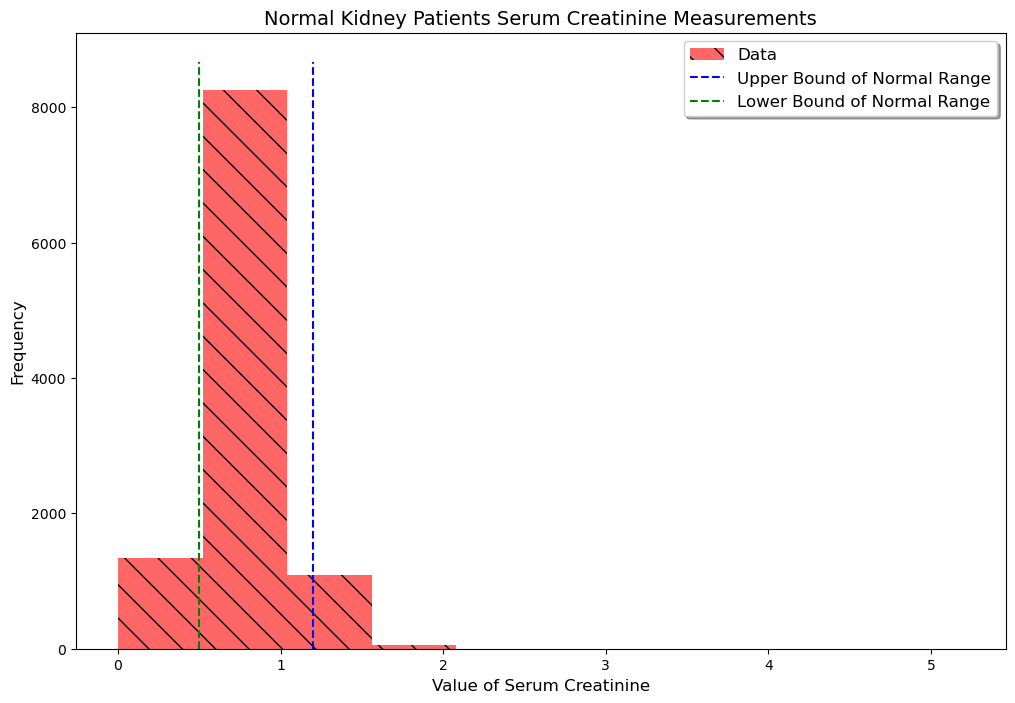

In [5]:
serum_creatinine_labs = normal_kidney_df.loc[normal_kidney_df['itemid'] == 50912]
serum_creatinine_lb = np.max(serum_creatinine_labs['ref_range_lower'])
serum_creatinine_ub = np.max(serum_creatinine_labs['ref_range_upper'])
plt.figure(figsize = (12, 8))
n, bins, patches = plt.hist(serum_creatinine_labs['valuenum'],
        color = 'red',
        hatch = '\\',
        alpha = 0.6,
        label = 'Data')
plt.plot([serum_creatinine_ub, serum_creatinine_ub],
        [0, 1.05*np.max(n)],
        'b--',
        label = 'Upper Bound of Normal Range')
plt.plot([serum_creatinine_lb, serum_creatinine_lb],
        [0, 1.05*np.max(n)],
        'g--',
        label = 'Lower Bound of Normal Range')
plt.xlabel('Value of Serum Creatinine',
          fontsize = 12)
plt.ylabel('Frequency',
          fontsize = 12)
plt.title('Normal Kidney Patients Serum Creatinine Measurements', 
         fontsize = 14)
plt.legend(loc = 'upper right',
          fancybox = True,
          shadow = True,
          fontsize = 12)
plt.show()

In [7]:
n_high_labs = serum_creatinine_labs.loc[serum_creatinine_labs['valuenum'] >= serum_creatinine_ub].shape[0]
n_labs = serum_creatinine_labs.shape[0]
print('Out of all of the serum creatinine readings, the proportion of values that are higher than normal is', np.round(n_high_labs/n_labs, 4), '\n')
print('The mean serum creatinine reading is', np.round(np.mean(serum_creatinine_labs['valuenum']), 4), '\n')
print('The standard deviation of the serum creatinine reading is', np.round(np.std(serum_creatinine_labs['valuenum']), 4), '\n')
print('The first quartile of the serum creatinine readings is', serum_creatinine_labs['valuenum'].quantile(0.25), '\n')
print('The second quartile of the serum creatinine readings is', serum_creatinine_labs['valuenum'].quantile(0.5), '\n')
print('The third quartile of the serum creatinine readings is', serum_creatinine_labs['valuenum'].quantile(0.75))


Out of all of the serum creatinine readings, the proportion of values that are higher than normal is 0.0557 

The mean serum creatinine reading is 0.7844 

The standard deviation of the serum creatinine reading is 0.2252 

The first quartile of the serum creatinine readings is 0.6 

The second quartile of the serum creatinine readings is 0.8 

The third quartile of the serum creatinine readings is 0.9


There are several important takeaways from the histogram and summary statistics shown above. First, for patients with normal kidneys, high serum creatinine readings are quite rare. Visually, this can be seen from the fact that the three bins which contain the majority lie within (or close to) the normal range. From the perspective of the summary statistics, only about $6\%$ of the readings are abnormally high (compared to $63\%$ for patients with kidney disease). All of these findings agree with the expectation that patients with kidney disease have abnormally high serum albumin. 

The second lab measurement that was analyzed in `kidney_disease_patients_eda.ipynb` is serum albumin (`itemid` = 50862). In regard to this lab measurement, our hypothesis is that low serum albumin is a precursor of kidney disease. Below we produce a histogram and summary statistics for serum albumin lab measurements to assess the validity of this hypothesis. 

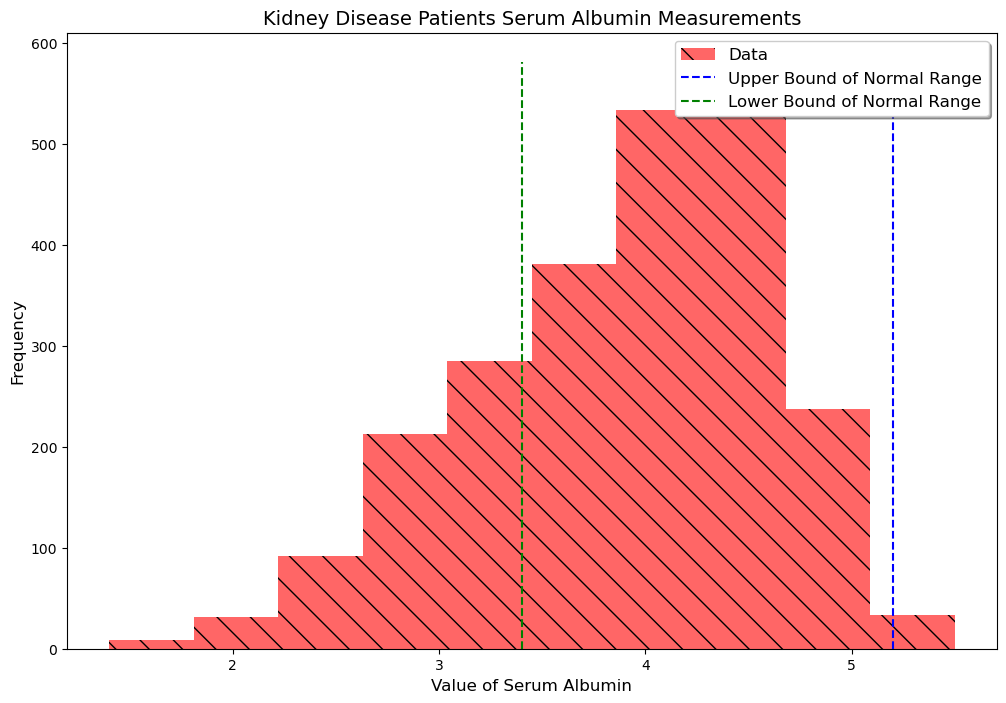

In [8]:
serum_albumin_labs = normal_kidney_df.loc[normal_kidney_df['itemid'] == 50862]
serum_albumin_lb = np.min(serum_albumin_labs['ref_range_lower'])
serum_albumin_ub = np.max(serum_albumin_labs['ref_range_upper'])
plt.figure(figsize = (12, 8))
n, bins, patches = plt.hist(serum_albumin_labs['valuenum'],
                           color = 'red',
                           hatch = '\\',
                           alpha = 0.6, 
                           label = 'Data')
plt.plot([serum_albumin_ub, serum_albumin_ub],
        [0, 1.05*np.max(n)],
        'b--',
        label = 'Upper Bound of Normal Range')
plt.plot([serum_albumin_lb, serum_albumin_lb],
        [0, 1.05*np.max(n)],
        'g--',
        label = 'Lower Bound of Normal Range')
plt.xlabel('Value of Serum Albumin',
          fontsize = 12)
plt.ylabel('Frequency',
          fontsize = 12)
plt.title('Kidney Disease Patients Serum Albumin Measurements', 
         fontsize = 14)
plt.legend(loc = 'upper right',
          fancybox = True,
          shadow = True,
          fontsize = 12)
plt.show()


In [10]:
n_low_labs = serum_albumin_labs.loc[serum_albumin_labs['valuenum'] <= serum_albumin_lb].shape[0]
n_labs = serum_albumin_labs.shape[0]
print('Out of all of the serum albumin readings, the proportion of values that are lower than normal is', np.round(n_low_labs/n_labs, 4), '\n')
print('The mean serum albumin reading is', np.round(np.mean(serum_albumin_labs['valuenum']), 4), '\n')
print('The standard deviation of the serum albumin reading is', np.round(np.std(serum_albumin_labs['valuenum']), 4), '\n')
print('The first quartile of the serum albumin readings is', serum_albumin_labs['valuenum'].quantile(0.25), '\n')
print('The second quartile of the serum albumin readings is', serum_albumin_labs['valuenum'].quantile(0.5), '\n')
print('The third quartile of the serum albumin readings is', serum_albumin_labs['valuenum'].quantile(0.75))

Out of all of the serum albumin readings, the proportion of values that are lower than normal is 0.266 

The mean serum albumin reading is 3.8753 

The standard deviation of the serum albumin reading is 0.6973 

The first quartile of the serum albumin readings is 3.4 

The second quartile of the serum albumin readings is 4.0 

The third quartile of the serum albumin readings is 4.4


Similar to the case of patients with kidney disease, the histogram indicates that many of the serum albumin readings fall within the normal range. However, as may be seen from the summary statistics, the proportion of serum albumin readings that are abnormally low is less in the case of patients with normal kidneys ($27\%$ compared to $35\%$). Furthermore, the mean and quartiles are higher for patients with normal kidneys, with a lower standard deviation for the mean. 
